In [1]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from scipy.interpolate import CubicSpline

warnings.filterwarnings("ignore")

from utils import *
from utils.data_loader import load_data
import seaborn as sns

In [2]:
final_clean_strained = load_data(db_level=0)

In [3]:
final_clean_strained

,Subject,Frequency(kHz),Level(dB),Amplitude,vx,SynapsesPerIHC,IHCs,OrphansPerIHC,Waveform,WaveI,Peaks,Troughs,Strain,Sex,Group,Noise,Time (str),Time (hrs),Strain (binary)
0,WPZ145,45.2,70.0,0.065036,v1,8.750000,8.8,1.136364,0 -0.112169 1 -0.113246 2 -0.12227...,24 0.085347 25 0.052718 26 0.054619 2...,"[34, 72, 101, 126, 156]","[65, 92, 111, 139, 167]",C57B6,M,98dB 8wks post,0.98,8wks,56.0,1
0,WPZ145,45.2,70.0,0.065036,v2,10.888889,9,1.222222,0 -0.112169 1 -0.113246 2 -0.12227...,24 0.085347 25 0.052718 26 0.054619 2...,"[34, 72, 101, 126, 156]","[65, 92, 111, 139, 167]",C57B6,M,98dB 8wks post,0.98,8wks,56.0,1
1,WPZ145,45.2,75.0,0.034276,v1,8.750000,8.8,1.136364,0 -0.111887 1 -0.099311 2 -0.07184...,31 -0.177462 32 -0.163745 33 -0.166343 3...,"[41, 95, 142, 175, 209]","[65, 132, 157, 189]",C57B6,M,98dB 8wks post,0.98,8wks,56.0,1
1,WPZ145,45.2,75.0,0.034276,v2,10.888889,9,1.222222,0 -0.111887 1 -0.099311 2 -0.07184...,31 -0.177462 32 -0.163745 33 -0.166343 3...,"[41, 95, 142, 175, 209]","[65, 132, 157, 189]",C57B6,M,98dB 8wks post,0.98,8wks,56.0,1
2,WPZ145,45.2,80.0,0.153990,v1,8.750000,8.8,1.136364,0 -0.021953 1 -0.030063 2 -0.01473...,44 0.052491 45 0.061552 46 0.070517 4...,"[54, 89, 154, 192, 210]","[63, 128, 173, 200, 212]",C57B6,M,98dB 8wks post,0.98,8wks,56.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7328,WPZ101,32.0,60.0,1.635883,v2,15.463918,9.7,0.000000,0 -0.048551 1 -0.010029 2 -0.02498...,23 0.206272 24 0.204751 25 0.213115 2...,"[33, 52, 79, 101, 165]","[43, 67, 92, 154, 187]",C57B6,M,8wks ctrl,0.00,8wks,56.0,1
7329,WPZ101,32.0,70.0,1.771467,v1,16.923077,9.1,0.000000,0 -0.027782 1 -0.022587 2 -0.06326...,22 -0.028416 23 -0.037919 24 0.001109 2...,"[32, 51, 77, 101, 135]","[42, 66, 90, 117, 146]",C57B6,M,8wks ctrl,0.00,8wks,56.0,1
7329,WPZ101,32.0,70.0,1.771467,v2,15.463918,9.7,0.000000,0 -0.027782 1 -0.022587 2 -0.06326...,22 -0.028416 23 -0.037919 24 0.001109 2...,"[32, 51, 77, 101, 135]","[42, 66, 90, 117, 146]",C57B6,M,8wks ctrl,0.00,8wks,56.0,1
7330,WPZ101,32.0,80.0,1.879935,v1,16.923077,9.1,0.000000,0 -0.036950 1 -0.055197 2 -0.07344...,21 0.052257 22 0.112573 23 0.155149 2...,"[31, 50, 75, 97, 209]","[39, 67, 88, 144]",C57B6,M,8wks ctrl,0.00,8wks,56.0,1


In [ ]:
def find_crossings(wave, zero=False):
    if not zero:
        baseline = (wave[-1] + wave[0]) / 2
    else:
        baseline = 0
    x_axis = range(len(wave))
    zero_crossings = np.where(np.diff(np.sign(wave - baseline)))[0]
    return [x_axis[indice] for indice in zero_crossings]


def find_wave_1(wave, peaks, troughs):
    start = find_crossings(wave[: peaks[0]], True)[-1]
    mid = peaks[0] + find_crossings(wave[peaks[0] : troughs[0] + 1])[0]
    end = troughs[0] + find_crossings(wave[troughs[0] : peaks[1] + 1])[0]
    return start, mid, end


def calculate_slope(x1, x2, y1, y2):
    if x2 - x1 == 0:
        return float("inf")
    s = (y2 - y1) / (x2 - x1)
    return s


def calculate_variance(wave, start, end):
    waveI = wave[start : end + 1]
    return np.sum((waveI - np.mean(waveI)) ** 2)


def calculate_curvature(wave, point):
    x_axis = np.linspace(0, 17, len(wave))
    idx = range(point - 10, point + 11)
    x = x_axis[idx]
    y = wave[idx]
    cs = CubicSpline(x, y)
    values = x_axis[point - 3 : point + 4 : 3]
    return np.abs(cs(values, 2)) / (1 + cs(values, 1) ** 2) ** (3 / 2)

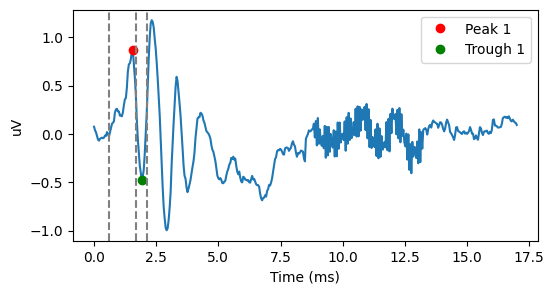

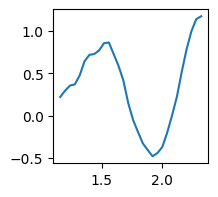

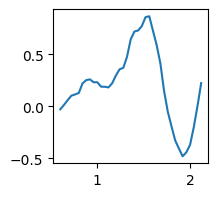

-3.77291666666667


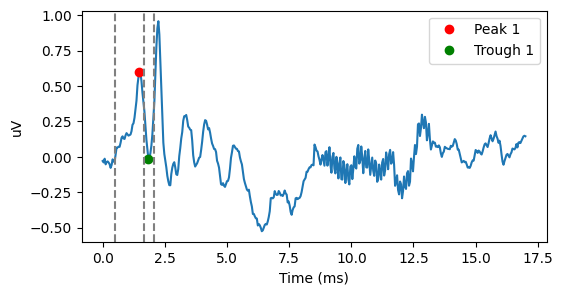

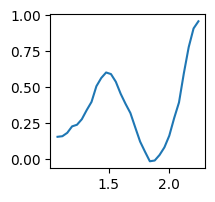

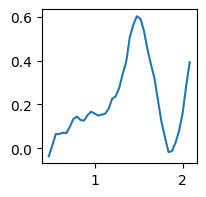

-1.41223


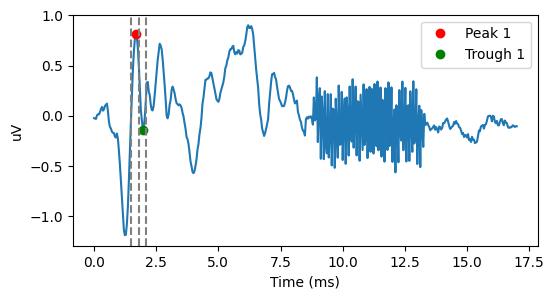

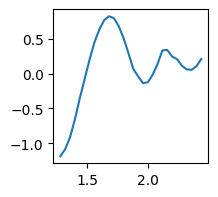

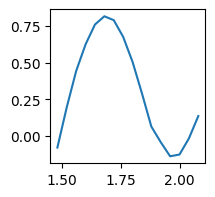

-2.592366666666664


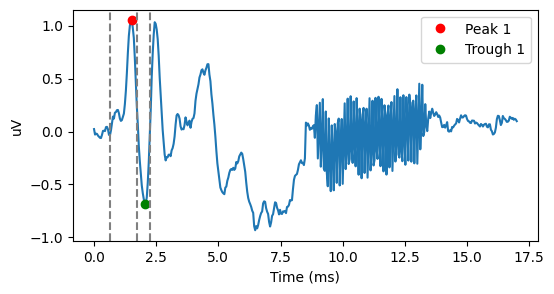

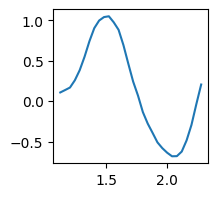

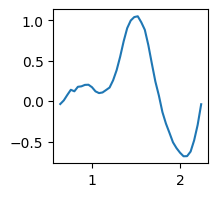

-4.0447250000000015


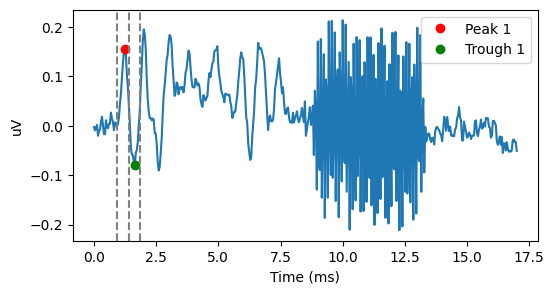

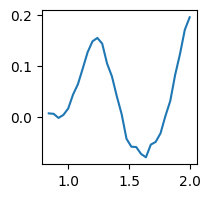

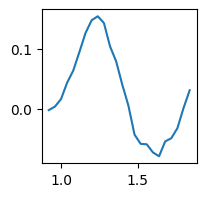

-0.7135562499999993


In [5]:
final_clean_strained_70 = final_clean_strained[final_clean_strained["Level(dB)"] >= 70]
final_clean_strained_80 = final_clean_strained[final_clean_strained["Level(dB)"] == 80]

# choose random 5 samples to plot:
random_samples = final_clean_strained_80.sample(n=5, random_state=10)
for idx, sample in random_samples.iterrows():
    plt.figure(figsize=(6, 3))
    x = np.linspace(0, 17, len(sample["Waveform"]))
    plt.plot(x, sample["Waveform"])
    plt.plot(
        x[sample["Peaks"]][0],
        sample["Waveform"][sample["Peaks"]][0],
        "ro",
        label="Peak 1",
    )
    plt.plot(
        x[sample["Troughs"]][0],
        sample["Waveform"][sample["Troughs"]][0],
        "go",
        label="Trough 1",
    )
    start, mid, end = find_wave_1(
        sample["Waveform"], sample["Peaks"], sample["Troughs"]
    )
    plt.axvline(x=x[start], linestyle="--", color="gray")
    plt.axvline(x=x[end], linestyle="--", color="gray")
    plt.axvline(x=x[mid], linestyle="--", color="gray")
    plt.xlabel("Time (ms)")
    plt.ylabel("uV")
    plt.legend()
    plt.show()
    plt.figure(figsize=(2, 2))
    plt.plot(x[sample["Peaks"][0] - 10 : sample["Peaks"][0] + 20], sample["WaveI"])
    plt.figure(figsize=(2, 2))
    plt.plot(
        x[start : end + 1],
        sample["Waveform"][start : end + 1],
    )
    plt.show()
    print(
        calculate_slope(
            x[sample["Peaks"][0]],
            x[mid],
            sample["Waveform"][sample["Peaks"][0]],
            sample["Waveform"][mid],
        )
    )

In [10]:
sample = final_clean_strained_80.iloc[48]
peak = sample["Peaks"][0]
x = np.linspace(0, 17, len(sample["Waveform"]))[peak - 2 : peak + 3]
y = sample["Waveform"][peak - 2 : peak + 3 : 2]
y

34    1.003217
36    1.119541
38    1.041865
Name: 10, dtype: float64

In [11]:
start, mid, end = find_wave_1(sample["Waveform"], sample["Peaks"], sample["Troughs"])
calculate_variance(sample["Waveform"], start, end)

11.063428658820051